# 04a — Conditional VAE Generator

**What this notebook does**: trains a Conditional Variational Autoencoder (CVAE)
to generate synthetic log-signatures of energy price paths.

**Input**: `data/logsigs.parquet`, `data/norm_stats.json` (from notebook 03)

**Outputs**:
- `data/cvae_model.pt` — trained CVAE weights
- `data/cvae_generated_logsigs.parquet` — 10,000 generated log-signatures

---

## Mathematical background

### VAE objective

A VAE learns a latent variable model $p_\theta(x) = \int p_\theta(x|z) p(z) dz$
by maximising the Evidence Lower Bound (ELBO):

$$\mathcal{L}(\theta, \phi) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
- \text{KL}(q_\phi(z|x) \| p(z))$$

The first term is the **reconstruction loss** — how well the decoder
reconstructs $x$ from the latent code $z$.
The second term is the **KL regulariser** — it keeps the posterior
$q_\phi(z|x)$ close to the prior $p(z) = \mathcal{N}(0, I)$.

### Conditional extension

In a CVAE the encoder and decoder both receive a conditioning vector $c$:

$$\mathcal{L}(\theta, \phi) = \mathbb{E}_{q_\phi(z|x,c)}[\log p_\theta(x|z,c)]
- \text{KL}(q_\phi(z|x,c) \| p(z))$$

Our conditioning vector $c_t$ contains:
- Realised volatility of the current segment
- Mean wind percentage
- Fourier seasonality features (sin/cos of month and hour)
- Regime one-hot encoding (calm / volatile / spike)
- Log-signature of the **previous** segment (enables sequential generation)

### Why VAE over GAN for small data

GANs require sufficient data to reach a generator-discriminator equilibrium.
With ~700 segments (4 years × ~175 weeks) this is a small dataset by deep
learning standards. VAEs optimise a tractable lower bound and converge
reliably with far fewer samples — exactly the regime of Bühl er et al. (2020).

### Connection to the universal approximation theorem

The decoder $f_\theta : \mathbb{R}^{d_z} \times \mathbb{R}^{d_c} \to \mathbb{R}^{d_s}$
is a feedforward neural network. By the UAT (Hornik 1991), it can approximate
any continuous function on a compact set — including the mapping from
(latent code, market state) to log-signature. This is the same UAT argument
used in your dissertation to justify the neural network option pricer.


In [1]:
%pip install -q torch polars pyarrow matplotlib numpy scikit-learn

In [2]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/energy_synthetic_data/data


In [3]:
import json
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# Device: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PyTorch version: 2.10.0+cu128
Device: cuda


In [4]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pl.read_parquet(DATA_DIR / "logsigs.parquet")
df = df.sort("start_time")

with open(DATA_DIR / "norm_stats.json") as f:
    norm_stats = json.load(f)

logsig_dim  = norm_stats["logsig_dim"]
seg_length  = norm_stats["seg_length"]

print(f"Loaded {df.shape[0]:,} log-signature segments")
print(f"Log-signature dimension: {logsig_dim}")
print(f"Regime distribution:")
print(df["regime"].value_counts())

Loaded 1,455 log-signature segments
Log-signature dimension: 90
Regime distribution:
shape: (2, 2)
┌────────┬───────┐
│ regime ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ spike  ┆ 2     │
│ calm   ┆ 1453  │
└────────┴───────┘


---
## 1. Feature preparation

We build two tensors:
- **X**: the log-signatures (what the CVAE learns to generate)
- **C**: the conditioning vector (what the CVAE conditions on)

The conditioning vector $c$ includes:
- Standardised realised volatility
- Standardised mean wind
- Fourier seasonality (sin/cos month, sin/cos hour)
- Regime one-hot (3 dims)
- Lagged log-signature (the log-signature of the previous segment)

The lagged log-signature is what enables **sequential generation**:
at inference time we can chain segments together by feeding each
generated log-signature back as the conditioning for the next.


In [5]:
# ── Extract log-signature columns ────────────────────────────────────────────
ls_cols = [c for c in df.columns if c.startswith("ls_")]
X_raw   = df.select(ls_cols).to_numpy().astype(np.float32)

# ── Standardise log-signatures ────────────────────────────────────────────────
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw).astype(np.float32)

print(f"X (log-signatures): {X_scaled.shape}")
print(f"X mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")

X (log-signatures): (1455, 90)
X mean: -0.0000, std: 0.9944


In [6]:
# ── Build conditioning vector ─────────────────────────────────────────────────

# Scalar conditioning features
scaler_C = StandardScaler()
scalar_feats = df.select([
    "realised_vol", "mean_wind",
    "sin_month", "cos_month",
    "sin_hour",  "cos_hour",
]).to_numpy().astype(np.float32)
scalar_feats_scaled = scaler_C.fit_transform(scalar_feats).astype(np.float32)

# Regime one-hot encoding
regime_map  = {"calm": 0, "volatile": 1, "spike": 2}
regime_list = df["regime"].to_list()
regime_idx  = np.array([regime_map.get(r, 0) for r in regime_list], dtype=np.int64)
regime_onehot = np.eye(3, dtype=np.float32)[regime_idx]

# Lagged log-signature (previous segment)
# Shift X by 1 — first segment gets zeros
X_lagged = np.zeros_like(X_scaled)
X_lagged[1:] = X_scaled[:-1]

# Concatenate all conditioning features
C = np.concatenate([
    scalar_feats_scaled,   # 6 dims
    regime_onehot,         # 3 dims
    X_lagged,              # logsig_dim dims (lagged log-sig)
], axis=1).astype(np.float32)

cond_dim = C.shape[1]
print(f"C (conditioning): {C.shape}")
print(f"  Scalar features:    6")
print(f"  Regime one-hot:     3")
print(f"  Lagged log-sig:     {logsig_dim}")
print(f"  Total cond_dim:     {cond_dim}")

C (conditioning): (1455, 99)
  Scalar features:    6
  Regime one-hot:     3
  Lagged log-sig:     90
  Total cond_dim:     99


In [7]:
# ── Train / validation split ──────────────────────────────────────────────────
# Temporal split: first 80% train, last 20% validation
# Never shuffle time series data randomly!
n = len(X_scaled)
n_train = int(0.8 * n)

X_train, X_val = X_scaled[:n_train], X_scaled[n_train:]
C_train, C_val = C[:n_train],        C[n_train:]

# PyTorch tensors
X_train_t = torch.tensor(X_train).to(device)
C_train_t = torch.tensor(C_train).to(device)
X_val_t   = torch.tensor(X_val).to(device)
C_val_t   = torch.tensor(C_val).to(device)

# DataLoader
BATCH_SIZE = 32
train_ds = TensorDataset(X_train_t, C_train_t)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train: {n_train:,} segments")
print(f"Val:   {n - n_train:,} segments")
print(f"Batch size: {BATCH_SIZE}")

Train: 1,164 segments
Val:   291 segments
Batch size: 32


---
## 2. CVAE architecture

Architecture follows Bühl er et al. (2020):
- **Encoder**: $[x; c] \to$ hidden $\to (\mu_z, \log\sigma^2_z)$
- **Decoder**: $[z; c] \to$ hidden $\to \hat{x}$
- Hidden layers: 2 layers of 256 units, LeakyReLU activations
- Latent dimension: 32
- Dropout: 0.1 for regularisation

The reparameterisation trick makes the sampling step differentiable:
$$z = \mu_z + \sigma_z \odot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$


In [8]:
class Encoder(nn.Module):
    def __init__(self, input_dim, cond_dim, hidden_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
        )
        self.mu      = nn.Linear(hidden_dim, latent_dim)
        self.log_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, c):
        h       = self.net(torch.cat([x, c], dim=1))
        mu      = self.mu(h)
        log_var = self.log_var(h)
        return mu, log_var


class Decoder(nn.Module):
    def __init__(self, latent_dim, cond_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=1))


class CVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, hidden_dim=256, latent_dim=32):
        super().__init__()
        self.encoder = Encoder(input_dim, cond_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, cond_dim, hidden_dim, input_dim)
        self.latent_dim = latent_dim

    def reparameterise(self, mu, log_var):
        """Reparameterisation trick: z = mu + sigma * eps, eps ~ N(0,I)."""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x, c):
        mu, log_var = self.encoder(x, c)
        z           = self.reparameterise(mu, log_var)
        x_hat       = self.decoder(z, c)
        return x_hat, mu, log_var

    def generate(self, c, n_samples=1):
        """Generate new log-signatures given conditioning vector c."""
        with torch.no_grad():
            z     = torch.randn(n_samples, self.latent_dim).to(c.device)
            x_hat = self.decoder(z, c)
        return x_hat


# Instantiate
LATENT_DIM  = 32
HIDDEN_DIM  = 256

model = CVAE(
    input_dim  = logsig_dim,
    cond_dim   = cond_dim,
    hidden_dim = HIDDEN_DIM,
    latent_dim = LATENT_DIM,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"CVAE architecture:")
print(f"  Input dim (log-sig):    {logsig_dim}")
print(f"  Conditioning dim:       {cond_dim}")
print(f"  Hidden dim:             {HIDDEN_DIM}")
print(f"  Latent dim:             {LATENT_DIM}")
print(f"  Trainable parameters:   {n_params:,}")

CVAE architecture:
  Input dim (log-sig):    90
  Conditioning dim:       99
  Hidden dim:             256
  Latent dim:             32
  Trainable parameters:   253,594


---
## 3. Training

The ELBO loss has two components:

$$\mathcal{L} = \underbrace{\|x - \hat{x}\|^2_2}_{\text{reconstruction}} +
\beta \cdot \underbrace{\text{KL}(q_\phi(z|x,c) \| p(z))}_{\text{regularisation}}$$

The $\beta$ parameter controls the tradeoff between reconstruction quality
and the smoothness of the latent space. We use $\beta$-VAE annealing:
start with $\beta=0$ (pure reconstruction) and linearly increase to $\beta=1$
over the first 50 epochs. This prevents posterior collapse in early training.

The KL term has an analytic form for Gaussian posteriors:
$$\text{KL}(\mathcal{N}(\mu, \sigma^2) \| \mathcal{N}(0,1)) =
\frac{1}{2}\sum_j (\mu_j^2 + \sigma_j^2 - \log\sigma_j^2 - 1)$$


In [10]:
def elbo_loss(x, x_hat, mu, log_var, beta=1.0):
    """ELBO loss = reconstruction + beta * KL divergence."""
    # Reconstruction: mean squared error over log-signature dimensions
    recon = F.mse_loss(x_hat, x, reduction="mean")

    # KL divergence: analytic form for Gaussian posterior vs N(0,I) prior
    # KL = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

    return recon + beta * kl, recon.item(), kl.item()


# Optimiser
LR        = 1e-3
N_EPOCHS  = 200
BETA_MAX  = 1.0
BETA_WARMUP = 50  # epochs to reach beta_max

optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode="min", factor=0.5, patience=20
)

print(f"Training for {N_EPOCHS} epochs")
print(f"Learning rate: {LR}, beta warmup: {BETA_WARMUP} epochs")

Training for 200 epochs
Learning rate: 0.001, beta warmup: 50 epochs


In [11]:
# ── Training loop ─────────────────────────────────────────────────────────────
train_losses = []
val_losses   = []
recon_losses = []
kl_losses    = []

best_val_loss = float("inf")
best_epoch    = 0

for epoch in tqdm(range(N_EPOCHS), desc="Training CVAE"):

    # Beta annealing: linearly increase from 0 to BETA_MAX over BETA_WARMUP epochs
    beta = min(BETA_MAX, BETA_MAX * epoch / BETA_WARMUP)

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss  = 0.0
    epoch_recon = 0.0
    epoch_kl    = 0.0

    for x_batch, c_batch in train_dl:
        optimiser.zero_grad()
        x_hat, mu, log_var = model(x_batch, c_batch)
        loss, recon, kl    = elbo_loss(x_batch, x_hat, mu, log_var, beta)
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        epoch_loss  += loss.item()
        epoch_recon += recon
        epoch_kl    += kl

    epoch_loss  /= len(train_dl)
    epoch_recon /= len(train_dl)
    epoch_kl    /= len(train_dl)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        x_hat_val, mu_val, lv_val = model(X_val_t, C_val_t)
        val_loss, _, _ = elbo_loss(X_val_t, x_hat_val, mu_val, lv_val, beta)
        val_loss = val_loss.item()

    scheduler.step(val_loss)

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    recon_losses.append(epoch_recon)
    kl_losses.append(epoch_kl)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save(model.state_dict(), DATA_DIR / "cvae_model.pt")

    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | train={epoch_loss:.4f} "
              f"val={val_loss:.4f} recon={epoch_recon:.4f} "
              f"kl={epoch_kl:.4f} beta={beta:.2f}")

print(f"\nBest model: epoch {best_epoch+1}, val_loss={best_val_loss:.4f}")

# Reload best weights
model.load_state_dict(torch.load(DATA_DIR / "cvae_model.pt"))
print("Best weights loaded.")

Training CVAE:  10%|█         | 21/200 [00:03<00:25,  7.08it/s]

Epoch  20 | train=0.3693 val=0.3481 recon=0.2837 kl=0.2251 beta=0.38


Training CVAE:  20%|██        | 41/200 [00:06<00:22,  7.12it/s]

Epoch  40 | train=0.3549 val=0.3835 recon=0.2630 kl=0.1178 beta=0.78


Training CVAE:  30%|███       | 61/200 [00:09<00:19,  7.09it/s]

...

Epoch 160 | train=0.3041 val=0.3878 recon=0.2220 kl=0.0821 beta=1.00


Training CVAE:  90%|█████████ | 181/200 [00:26<00:02,  7.05it/s]

Epoch 180 | train=0.3036 val=0.3841 recon=0.2203 kl=0.0833 beta=1.00


Training CVAE: 100%|██████████| 200/200 [00:29<00:00,  6.85it/s]

Epoch 200 | train=0.2991 val=0.3893 recon=0.2181 kl=0.0810 beta=1.00

Best model: epoch 17, val_loss=0.3422
Best weights loaded.


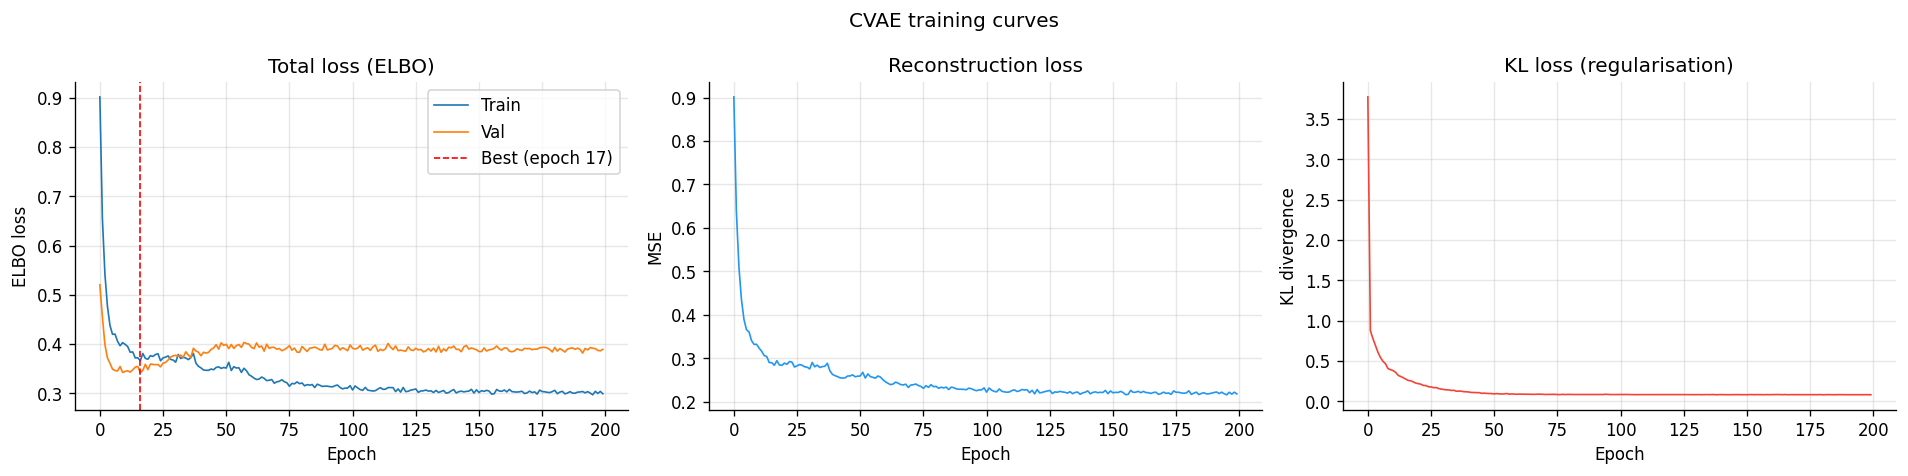

In [12]:
# ── Plot training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("CVAE training curves", fontsize=12)

ax = axes[0]
ax.plot(train_losses, label="Train", lw=1)
ax.plot(val_losses,   label="Val",   lw=1)
ax.axvline(best_epoch, color="red", ls="--", lw=1, label=f"Best (epoch {best_epoch+1})")
ax.set_xlabel("Epoch")
ax.set_ylabel("ELBO loss")
ax.set_title("Total loss (ELBO)")
ax.legend()

ax = axes[1]
ax.plot(recon_losses, color="#2196F3", lw=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Reconstruction loss")

ax = axes[2]
ax.plot(kl_losses, color="#F44336", lw=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("KL divergence")
ax.set_title("KL loss (regularisation)")

plt.tight_layout()
plt.savefig(DATA_DIR / "04a_training_curves.png", bbox_inches="tight")
plt.show()

---
## 4. Generation

We generate synthetic log-signatures by:
1. Sampling a conditioning vector $c$ from the empirical distribution
   (or constructing a specific scenario)
2. Sampling $z \sim \mathcal{N}(0, I)$
3. Decoding: $\hat{x} = f_\theta(z, c)$
4. Unnormalising with the scaler fitted on training data

For sequential generation we chain segments: the generated log-signature
at step $t$ becomes part of the conditioning vector at step $t+1$.


In [13]:
# ── Generate 10,000 synthetic log-signatures ──────────────────────────────────
model.eval()
N_GENERATE = 10_000

# Sample conditioning vectors from the training distribution
# (Bootstrap from real conditioning vectors)
np.random.seed(42)
idx = np.random.choice(len(C_train), size=N_GENERATE, replace=True)
C_gen = torch.tensor(C_train[idx]).to(device)

# Generate in batches
GEN_BATCH = 512
generated_logsigs = []

with torch.no_grad():
    for i in range(0, N_GENERATE, GEN_BATCH):
        c_batch = C_gen[i:i+GEN_BATCH]
        z       = torch.randn(len(c_batch), LATENT_DIM).to(device)
        x_hat   = model.decoder(z, c_batch)
        generated_logsigs.append(x_hat.cpu().numpy())

generated_logsigs = np.concatenate(generated_logsigs, axis=0)

# Unnormalise
generated_logsigs_unnorm = scaler_X.inverse_transform(generated_logsigs)

print(f"Generated {len(generated_logsigs):,} log-signatures")
print(f"Shape: {generated_logsigs_unnorm.shape}")

Generated 10,000 log-signatures
Shape: (10000, 90)


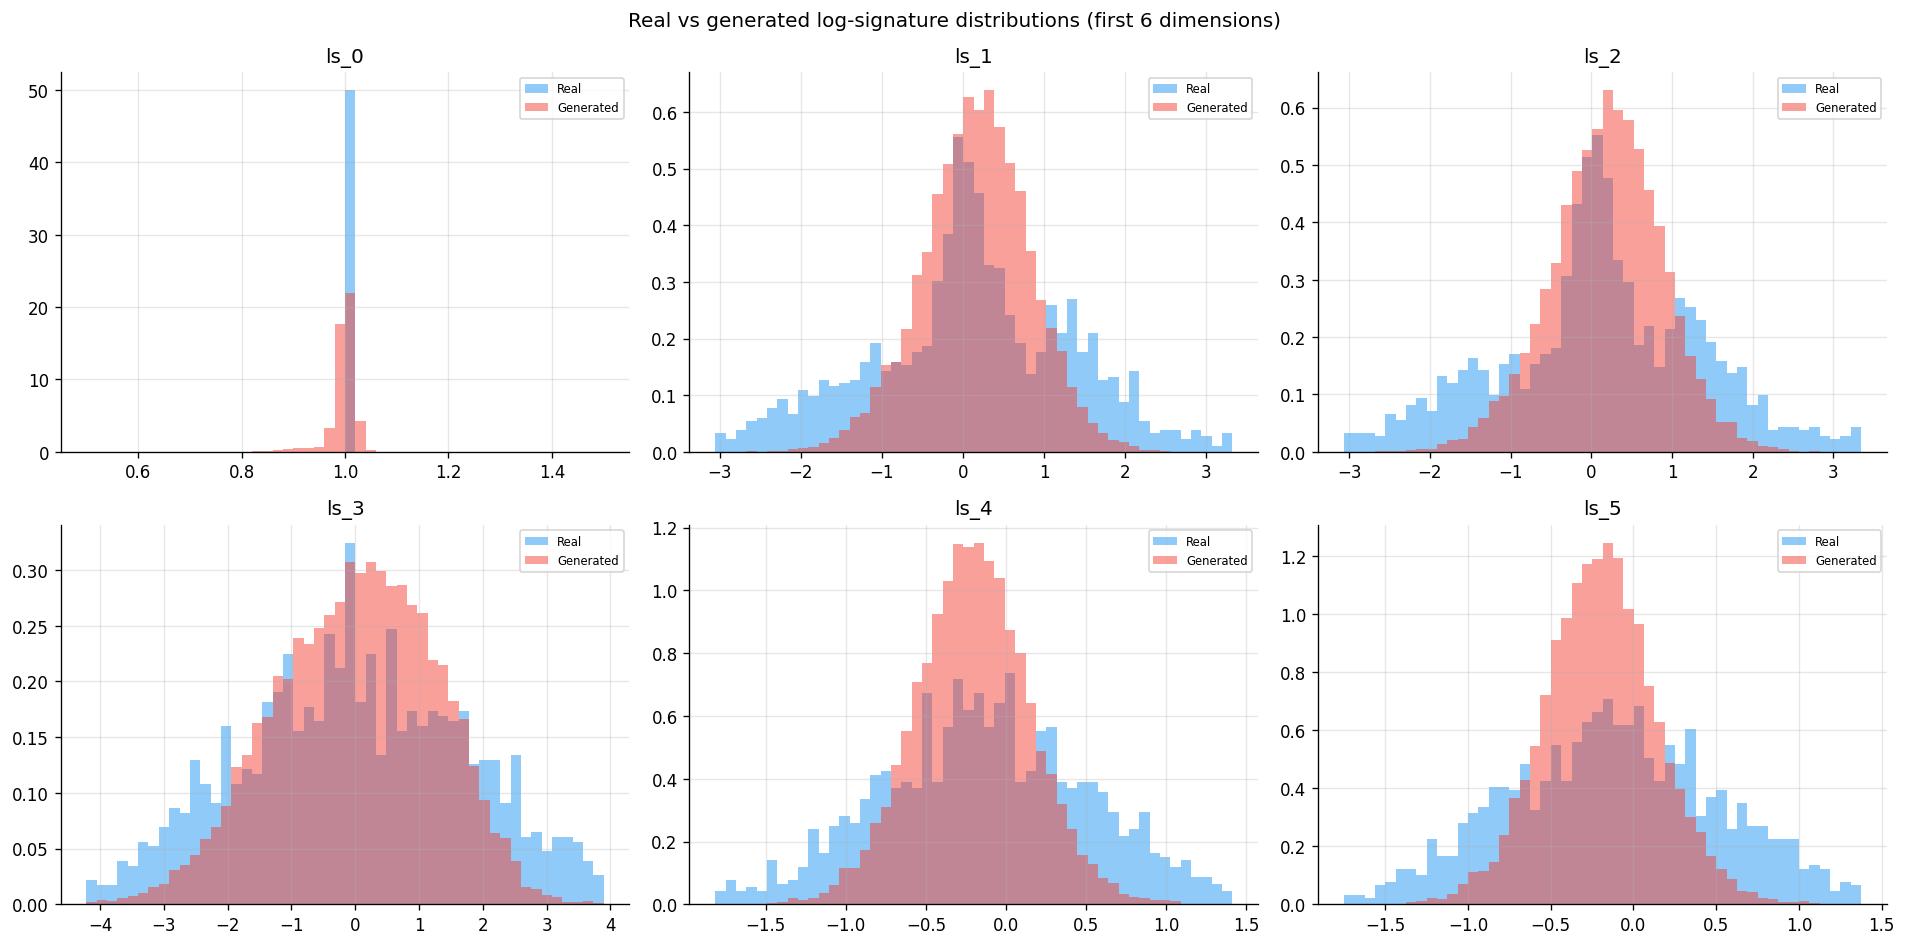

In [14]:
# ── Quick quality check: compare real vs generated distributions ───────────────
real_logsigs = scaler_X.inverse_transform(X_scaled)

# Check first 6 log-signature dimensions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Real vs generated log-signature distributions (first 6 dimensions)",
             fontsize=12)

for i, ax in enumerate(axes.flat):
    real_vals = real_logsigs[:, i]
    gen_vals  = generated_logsigs_unnorm[:, i]

    # Common range
    lo = np.percentile(real_vals, 1)
    hi = np.percentile(real_vals, 99)

    ax.hist(real_vals, bins=50, density=True, alpha=0.5,
            color="#2196F3", label="Real", range=(lo, hi))
    ax.hist(gen_vals,  bins=50, density=True, alpha=0.5,
            color="#F44336", label="Generated", range=(lo, hi))
    ax.set_title(f"ls_{i}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(DATA_DIR / "04a_logsig_distributions.png", bbox_inches="tight")
plt.show()

Generated 5 year-long chains
Each chain: 52 segments × 90 log-sig dims


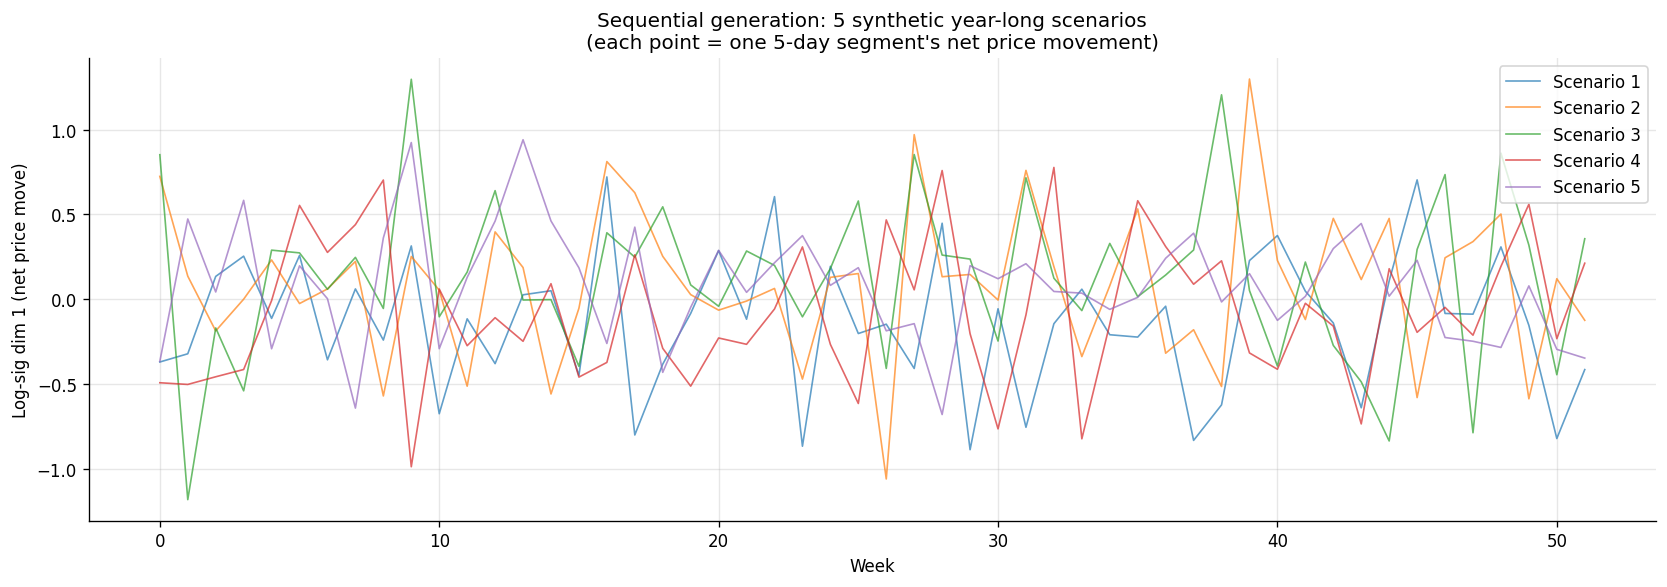

In [15]:
# ── Sequential generation: chain 52 weekly segments → 1 year ─────────────────
# This demonstrates the CVAE's ability to generate coherent long-horizon paths
# by conditioning each segment on the previous segment's log-signature

N_STEPS  = 52   # 52 weeks = 1 year
N_CHAINS = 5    # generate 5 independent year-long scenarios

model.eval()
chains = []

for chain_idx in range(N_CHAINS):
    chain_logsigs = []

    # Start from a random real conditioning vector
    start_idx = np.random.randint(0, len(C_train))
    c_scalar  = torch.tensor(C_train[start_idx:start_idx+1, :9]).to(device)  # first 9 dims
    prev_logsig = torch.zeros(1, logsig_dim).to(device)  # start from zero

    with torch.no_grad():
        for step in range(N_STEPS):
            # Build conditioning: scalar features + regime + prev logsig
            c = torch.cat([c_scalar, prev_logsig], dim=1)

            # Generate
            z      = torch.randn(1, LATENT_DIM).to(device)
            x_hat  = model.decoder(z, c)

            chain_logsigs.append(x_hat.cpu().numpy()[0])

            # Update: prev_logsig for next step = current generated logsig
            prev_logsig = x_hat

    chains.append(np.stack(chain_logsigs))

print(f"Generated {N_CHAINS} year-long chains")
print(f"Each chain: {N_STEPS} segments × {logsig_dim} log-sig dims")

# Plot the first log-sig dimension (net price move) over each chain
fig, ax = plt.subplots(figsize=(14, 5))
for i, chain in enumerate(chains):
    ax.plot(chain[:, 1], lw=1, alpha=0.7, label=f"Scenario {i+1}")
ax.set_xlabel("Week")
ax.set_ylabel("Log-sig dim 1 (net price move)")
ax.set_title("Sequential generation: 5 synthetic year-long scenarios\n"
             "(each point = one 5-day segment's net price movement)")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "04a_sequential_generation.png", bbox_inches="tight")
plt.show()

---
## 5. Save outputs


In [16]:
# ── Save generated log-signatures ─────────────────────────────────────────────

# Also retrieve which conditioning vector each generated sample used
cond_regimes = [regime_list[i] for i in idx]

gen_records = {
    "sample_id": list(range(N_GENERATE)),
    "regime":    cond_regimes,
}
for j in range(logsig_dim):
    gen_records[f"ls_{j}"] = generated_logsigs_unnorm[:, j].tolist()

df_gen = pl.DataFrame(gen_records)
out_path = DATA_DIR / "cvae_generated_logsigs.parquet"
df_gen.write_parquet(out_path)
print(f"Saved: cvae_generated_logsigs.parquet ({out_path.stat().st_size/1e6:.2f} MB)")

# Save scaler parameters for notebook 05
scaler_params = {
    "X_mean": scaler_X.mean_.tolist(),
    "X_scale": scaler_X.scale_.tolist(),
    "C_mean": scaler_C.mean_.tolist(),
    "C_scale": scaler_C.scale_.tolist(),
    "regime_map": regime_map,
    "latent_dim": LATENT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "cond_dim": cond_dim,
    "logsig_dim": logsig_dim,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
}
with open(DATA_DIR / "cvae_params.json", "w") as f:
    json.dump(scaler_params, f, indent=2)
print("Saved: cvae_params.json")

print("\nAll files in data directory:")
for fp in sorted(DATA_DIR.glob("*")):
    if fp.suffix in [".parquet", ".json", ".pt", ".png"]:
        print(f"  {fp.name}: {fp.stat().st_size/1e3:.1f} KB")

Saved: cvae_generated_logsigs.parquet (3.98 MB)
Saved: cvae_params.json

All files in data directory:
  01_raw_data_overview.png: 422.0 KB
  02a_return_distribution.png: 89.5 KB
  02b_seasonality.png: 90.1 KB
  02c_autocorrelation.png: 84.5 KB
  02d_spikes.png: 99.6 KB
  02e_wind_price.png: 154.1 KB
  02f_regimes.png: 143.6 KB
  03a_path_construction.png: 126.4 KB
  03b_signature_pca.png: 69.4 KB
  03c_levy_area.png: 78.0 KB
  04a_logsig_distributions.png: 80.0 KB
  04a_sequential_generation.png: 259.4 KB
  04a_training_curves.png: 88.4 KB
  carbon_intensity.parquet: 2350.3 KB
  cvae_generated_logsigs.parquet: 3979.6 KB
  cvae_model.pt: 1020.2 KB
  cvae_params.json: 5.0 KB
  elexon_generation.parquet: 3507.9 KB
  elexon_system_prices.parquet: 5590.7 KB
  logsigs.parquet: 1057.0 KB
  master.parquet: 10158.7 KB
  norm_stats.json: 0.2 KB
  returns.parquet: 873.3 KB
  stylized_facts.parquet: 1.3 KB


---
## Summary

| Component | Detail |
|-----------|--------|
| Architecture | CVAE with 2-layer encoder + decoder, LeakyReLU, dropout |
| Latent dim | 32 |
| Conditioning | Realised vol, wind, seasonality, regime, lagged log-sig |
| Training | 200 epochs, Adam, β-annealing, LR scheduling |
| Input | Log-signatures of 5-day price segments |
| Output | 10,000 synthetic log-signatures + 5 year-long scenarios |

**What to check in the distribution plots**: the red (generated) and blue (real)
histograms should broadly overlap for all 6 dimensions shown. If the generated
distribution is narrower it means the KL term is too dominant — reduce beta.
If the shapes diverge significantly, try more epochs or increase hidden_dim to 512.

**Next**: `05_validation.ipynb` — apply the signature MMD two-sample test to
rigorously compare the distribution of real vs generated paths on path space,
and check all stylized facts from notebook 02 against the generated data.
